In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import isautilities as isau
from matplotlib.colors import LinearSegmentedColormap

import pathlib
froot = pathlib.Path().cwd().parent.parent.parent / 'Results' / 'Figures' / 'ISIntervals'
session = '/mnt/hubel-data-139/perceval/Rat003_20231227/Rat003_20231227.xml'
regs = ["pfc","hpc","nr"]
states = ["sws","rem"]

In [2]:
# try colormap for isa example
R = fma.regions.regions(session,states=['sws','rem'],events='InfraSlowRhythm/infraslowaval')

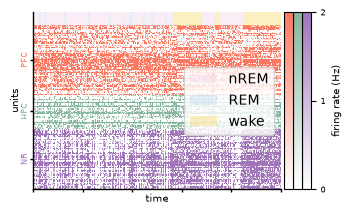

In [87]:
fig, ax = fma.plotting.makeFigure(size=(8.5,5),constrained_layout=False)
start = 1500
stop = start + 2500
label = ('firing rate (Hz)',' ',' ')
ticks = ([0,1,2],None,None)
n = [[0,0]]
cbs = []
for i, r in enumerate(['nr','hpc','pfc']):
    fr = R.unitFiringRate(regs=r,when=[start,stop],window=1)
    t = fr[:,0]
    fr = fr[:,1:]
    n.append([n[-1][1], n[-1][1]+len(R.units(regs=r))])
    im, cb = fma.plotting.plotColorMap(fr.T,x=t,y=n[-1],vmin=0,vmax=2,cmap=LinearSegmentedColormap.from_list(name=r,colors=['white',isau.paperColors(r)]),bar=label[i],barticks=ticks[i],interpolation='none')
    cbs.append(cb)
    if i != 0:
        cb.ax.set(yticks=[])
n = np.array(n)[1:]
ax[0].set(xlabel='time', xlim=(start,stop), xticklabels=[], ylim=(0,n[-1][1]+11), ylabel='units')
ax[0].set_yticks(n.mean(1), labels=['NR','HPC','PFC'], rotation=90, va='center')
ticks = ax[0].get_yticklabels()
for i, color in enumerate(isau.paperColors(['nr','hpc','pfc'])):
    ticks[i].set_color(color)

# states
label = ('nREM','REM','wake')
for i, state in enumerate(('sws','rem','other')):
    fma.plotting.plotIntervals(R.eventIntervals(state).astype(int), ymin=(n[-1][1]-0.5)/(n[-1][1]+11), color=isau.paperColors(state), label=label[i])
ax[0].legend(loc='right')

# set raster size
cm = 1 / 2.54
width_cm = 6.3
height_cm = 4.5
fig_w, fig_h = fig.get_size_inches()
width = width_cm * cm / fig_w
height = height_cm * cm / fig_h
ax[0].set_position([0.1,0.1,width,height])
pos = np.array(cbs[0].ax.get_position()).ravel()
pos[0] = 0.85
for cb in reversed(cbs):
    cb.ax.set_position([pos[0],0.1,0.03,height])
    pos[0] += 0.027

fma.plotting.saveFigure(fig,froot / 'isa_example',['png','svg'])

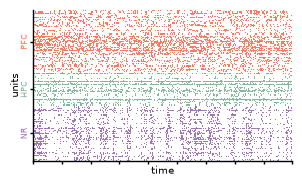

In [88]:
fig, ax = fma.plotting.makeFigure(size=(8.5,5),constrained_layout=False)
start = 2070
stop = start + 180
n = [[0,0]]
for i, r in enumerate(['nr','hpc','pfc']):
    fr = R.unitFiringRate(regs=r,when=[start,stop],window=0.25)
    t = fr[:,0]
    fr = fr[:,1:]
    n.append([n[-1][1], n[-1][1]+len(R.units(regs=r))])
    im = fma.plotting.plotColorMap(fr.T,x=t,y=n[-1],vmin=0,vmax=.0001,cmap=LinearSegmentedColormap.from_list(name=r,colors=['white',isau.paperColors(r)]),interpolation='none')
n = np.array(n)[1:]
ax[0].set(xlabel='time', xlim=(start,stop), xticks=np.arange(start,stop+1,20), xticklabels=[], ylim=(0,n[-1][1]), ylabel='units')
ax[0].set_yticks(n.mean(1), labels=['NR','HPC','PFC'], rotation=90, va='center')
ticks = ax[0].get_yticklabels()
for i, color in enumerate(isau.paperColors(['nr','hpc','pfc'])):
    ticks[i].set_color(color)
fma.plotting.saveFigure(fig,froot / 'isa_example_zoom',['png','svg'])

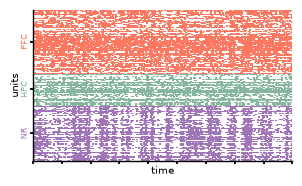

In [44]:
# old
fig, ax = fma.plotting.makeFigure(size=(8.5,5),constrained_layout=False)
start = 2070
stop = start + 180
n = [[0,0]]
for i, r in enumerate(['nr','hpc','pfc']):
    spikes = R.spikes(regs=r,when=[start,stop])
    n.append([n[-1][1], n[-1][1]+len(R.units(regs=r))])
    fma.plotting.plotRaster(spikes, color=isau.paperColors(r), compact=True, offset=n[-1][0])
n = np.array(n)[1:]
ax[0].set(xlabel='time', xlim=(start,stop), xticks=np.arange(start,stop+1,20), xticklabels=[], ylabel='units', ylim=(0,n[-1][1]))
ax[0].set_yticks(n.mean(1), labels=['NR','HPC','PFC'], rotation=90, va='center')
ticks = ax[0].get_yticklabels()
for i, color in enumerate(isau.paperColors(['nr','hpc','pfc'])):
    ticks[i].set_color(color)

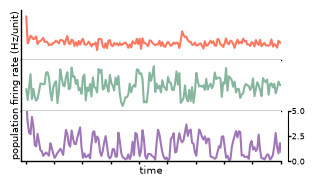

In [102]:
fig, ax = fma.plotting.figure(n=(3,1), size=(8.5,5), constrained_layout=False, gridspec_kw={'hspace':0})
start = 2070
stop = start + 180
regs = ['pfc','hpc','nr']
fr = R.firingRate(regs=regs, when=[start,stop], window=1, norm=True)
for i, r in enumerate(regs):
    ax[i].plot(fr[:,0],fr[:,i+1],color=isau.paperColors(r))
    ax[i].set(xlim=(start-3,stop), xticks=[], ylim=(0,5), yticks=())
ax[1].set_ylabel('population firing rate (Hz/unit)')
ax[1].yaxis.labelpad = 0.7
ax[-1].yaxis.tick_right(); ax[-1].set(yticks=(0,2.5,5))
ax[-1].spines['right'].set_visible(True); ax[-1].spines["right"].set_position(("outward",5))
ax[-1].set(xlabel='time', xticks=np.arange(start,stop+1,20), xticklabels=[])
#fig.text(0.06, 0.5, 'population firing rate (Hz/unit)', rotation="vertical", va="center", fontsize=7)
fma.plotting.saveFigure(fig,froot / 'isa_example_fr',['png','svg'])